# Chapter 24 Python Lab  
## Multivariable Calculus for Probability and Statistics

This lab accompanies **Chapter 24: Multivariable Calculus for Probability and Statistics**.

Probability and statistics use multivariable calculus constantly:

- joint densities are functions of several variables;
- probabilities are double and triple integrals;
- marginal and conditional densities are integrals and ratios;
- expectations are weighted integrals;
- covariance is an inner-product-like measurement;
- transformations of random variables require Jacobians;
- maximum likelihood uses gradients and Hessians;
- Bayesian inference uses multivariable integration and normalization;
- the multivariate normal distribution is shaped by quadratic forms.

This lab uses Python to explore these ideas computationally with `numpy` and `matplotlib`.

We will study:

- joint probability densities on rectangles and regions;
- normalization constants;
- marginal and conditional distributions;
- expectation, variance, covariance, and correlation;
- Monte Carlo integration;
- change of variables and Jacobians;
- bivariate normal geometry;
- likelihood surfaces, score functions, and Hessians;
- Fisher-information-style curvature;
- Bayesian posterior surfaces;
- and a mini-project on fitting a probabilistic model.

## Learning goals

By the end of this lab, you should be able to:

1. approximate probabilities from joint densities using double integrals;
2. compute and visualize marginal densities;
3. compute conditional densities from joint densities;
4. compute expectations and covariance from a joint density;
5. interpret independence geometrically and numerically;
6. apply change of variables to probability densities using Jacobians;
7. visualize bivariate normal contours and covariance ellipses;
8. interpret log-likelihoods as functions of parameters;
9. use gradients and Hessians to understand maximum likelihood;
10. approximate posterior distributions and posterior summaries.

## Source note

This notebook was generated from the uploaded Chapter 24 QMD file.  
The extracted early headings from the source file include:

- Multivariable Calculus for Probability and Statistics
- Learning goals
- 24.1 Random variables as functions and data as points
- Three spaces in statistics
- 24.2 Joint densities and probability as volume
- Example 24.1: A simple density on a square
- 24.3 Marginal densities
- Example 24.2: Marginals for $f(x,y)=x+y$
- Integrating out variables
- 24.4 Conditional densities and independence
- Example 24.3: Conditional density from a joint density
- Independence
- 24.5 Expectation as integration
- Example 24.4: Means and covariance for a simple joint density

## 0. Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
norm = np.linalg.norm

def make_grid(xmin, xmax, ymin, ymax, n=300):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y

def midpoint_grid(xmin, xmax, ymin, ymax, nx=400, ny=400):
    dx = (xmax - xmin)/nx
    dy = (ymax - ymin)/ny
    x = xmin + (np.arange(nx) + 0.5)*dx
    y = ymin + (np.arange(ny) + 0.5)*dy
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y, dx, dy

def safe_eval_2d(f, X, Y):
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        Z = f(X, Y)
    return np.asarray(Z, dtype=float)

def integrate_rect(f, xmin, xmax, ymin, ymax, nx=500, ny=500):
    x, y, X, Y, dx, dy = midpoint_grid(xmin, xmax, ymin, ymax, nx=nx, ny=ny)
    Z = safe_eval_2d(f, X, Y)
    return float(np.sum(Z)*dx*dy), X, Y, Z, dx, dy

def integrate_region(f, xmin, xmax, ymin, ymax, mask, nx=500, ny=500):
    x, y, X, Y, dx, dy = midpoint_grid(xmin, xmax, ymin, ymax, nx=nx, ny=ny)
    Z = safe_eval_2d(f, X, Y)
    inside = mask(X, Y)
    return float(np.sum(Z[inside])*dx*dy), X, Y, Z, inside, dx, dy

def marginal_x_from_grid(fxy, x, y, dy):
    return np.sum(fxy, axis=0)*dy

def marginal_y_from_grid(fxy, x, y, dx):
    return np.sum(fxy, axis=1)*dx

def expectation_from_density(g, f, xmin, xmax, ymin, ymax, nx=500, ny=500):
    val, *_ = integrate_rect(lambda X, Y: g(X, Y)*f(X, Y), xmin, xmax, ymin, ymax, nx=nx, ny=ny)
    return val

def plot_density_contour(f, xmin, xmax, ymin, ymax, n=300, title="Density contours", levels=20):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n=n)
    Z = safe_eval_2d(f, X, Y)
    plt.figure(figsize=(7, 6))
    cs = plt.contour(X, Y, Z, levels=levels)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True, alpha=0.25)
    plt.show()
    return X, Y, Z

def plot_density_heatmap(f, xmin, xmax, ymin, ymax, n=350, title="Density heatmap"):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n=n)
    Z = safe_eval_2d(f, X, Y)
    plt.figure(figsize=(7, 6))
    im = plt.imshow(Z, extent=[xmin, xmax, ymin, ymax], origin="lower", aspect="auto")
    plt.colorbar(im, label="density")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.grid(True, alpha=0.25)
    plt.show()
    return X, Y, Z

def finite_gradient(f, p, h=1e-5):
    p = np.asarray(p, dtype=float)
    g = np.zeros_like(p)
    for j in range(len(p)):
        step = np.zeros_like(p)
        step[j] = h
        g[j] = (f(p + step) - f(p - step))/(2*h)
    return g

def finite_hessian(f, p, h=1e-4):
    p = np.asarray(p, dtype=float)
    n = len(p)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ei = np.zeros(n); ej = np.zeros(n)
            ei[i] = h; ej[j] = h
            H[i,j] = (f(p+ei+ej) - f(p+ei-ej) - f(p-ei+ej) + f(p-ei-ej))/(4*h*h)
    return H

def bivariate_normal_pdf(X, Y, mu, Sigma):
    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)
    detS = np.linalg.det(Sigma)
    invS = np.linalg.inv(Sigma)
    DX = X - mu[0]
    DY = Y - mu[1]
    q = invS[0,0]*DX**2 + 2*invS[0,1]*DX*DY + invS[1,1]*DY**2
    return np.exp(-0.5*q)/(2*np.pi*np.sqrt(detS))

def covariance_ellipse_points(mu, Sigma, level=1.0, n=400):
    theta = np.linspace(0, 2*np.pi, n)
    circle = np.vstack([np.cos(theta), np.sin(theta)])
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    A = eigvecs @ np.diag(np.sqrt(eigvals))
    pts = np.asarray(mu)[:, None] + level*(A @ circle)
    return pts[0], pts[1]

def normalize_grid_density(W, dx, dy):
    total = np.sum(W)*dx*dy
    return W/total, total

def monte_carlo_expectation(g, sampler, n=100_000, seed=0):
    rng = np.random.default_rng(seed)
    samples = sampler(rng, n)
    vals = g(samples[:,0], samples[:,1])
    return float(np.mean(vals)), float(np.std(vals, ddof=1)/np.sqrt(n)), samples

print("Setup complete.")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-i1cits8k because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Setup complete.


---

# Part I. Joint densities and normalization

A joint density $f_{X,Y}(x,y)$ must satisfy:

$$
f_{X,Y}(x,y)\geq 0,
$$

and

$$
\iint_{\mathbb R^2} f_{X,Y}(x,y)\,dA=1.
$$

When a density is supported on a bounded region $D$, normalization means

$$
\iint_D f(x,y)\,dA=1.
$$

## 1. A density on the unit square

Consider

$$
f(x,y)=c(x+y)
$$

on

$$
0\leq x\leq1,\qquad 0\leq y\leq1.
$$

We choose $c$ so that the total probability is $1$.

Since

$$
\int_0^1\int_0^1(x+y)\,dy\,dx=1,
$$

we have $c=1$.

Integral of f(x,y)=x+y over unit square: 1.0


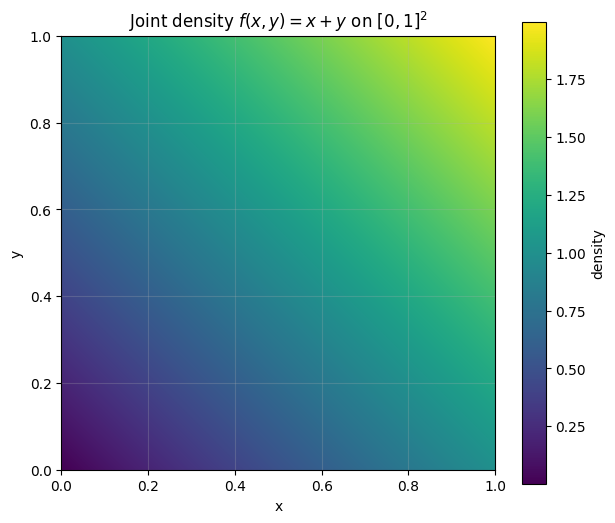

In [2]:
def f_square(X, Y):
    return X + Y

total_square, X, Y, Z, dx, dy = integrate_rect(f_square, 0, 1, 0, 1, nx=600, ny=600)

print("Integral of f(x,y)=x+y over unit square:", total_square)

plt.figure(figsize=(7, 6))
im = plt.imshow(Z, extent=[0,1,0,1], origin="lower", aspect="equal")
plt.colorbar(im, label="density")
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Joint density $f(x,y)=x+y$ on $[0,1]^2$")
plt.grid(True, alpha=0.25)
plt.show()

## 2. Probability of a subregion

Compute

$$
P(X+Y\leq1)
=
\int\!\!\int_{x+y\leq1}(x+y)\,dA
$$

over the unit square.

P(X+Y <= 1): 0.33404795918367347
Exact value: 0.3333333333333333


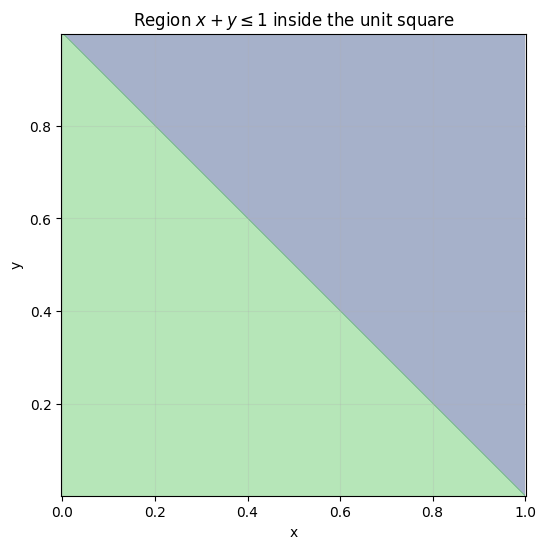

In [3]:
mask_triangle = lambda X, Y: (X >= 0) & (X <= 1) & (Y >= 0) & (Y <= 1) & (X + Y <= 1)

prob_triangle, X, Y, Z, inside, *_ = integrate_region(
    f_square,
    0, 1, 0, 1,
    mask_triangle,
    nx=700,
    ny=700
)

# Exact: ∫_0^1 ∫_0^{1-x} (x+y) dy dx = 1/3.
print("P(X+Y <= 1):", prob_triangle)
print("Exact value:", 1/3)

plt.figure(figsize=(6, 6))
plt.contourf(X, Y, inside.astype(float), levels=[-0.5,0.5,1.5], alpha=0.45)
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Region $x+y\leq1$ inside the unit square")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

## 3. Normalizing an unnormalized density

Suppose

$$
g(x,y)=e^{-x^2-y^2}
$$

on the square $[-2,2]^2$.

The normalized density is

$$
f(x,y)=\frac{g(x,y)}{\int_{-2}^2\int_{-2}^2g(x,y)\,dy\,dx}.
$$

Normalizer over [-2,2]^2: 3.112271023096249
Integral after normalization: 0.9999999999999999


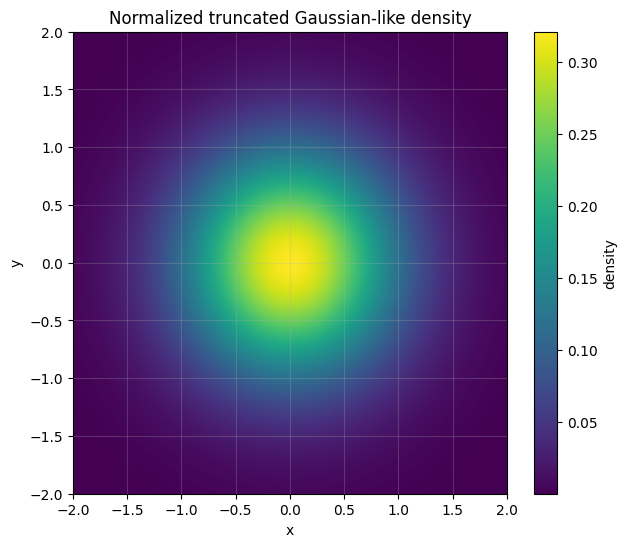

(array([[-2.      , -1.988539, -1.977077, ...,  1.977077,  1.988539,
          2.      ],
        [-2.      , -1.988539, -1.977077, ...,  1.977077,  1.988539,
          2.      ],
        [-2.      , -1.988539, -1.977077, ...,  1.977077,  1.988539,
          2.      ],
        ...,
        [-2.      , -1.988539, -1.977077, ...,  1.977077,  1.988539,
          2.      ],
        [-2.      , -1.988539, -1.977077, ...,  1.977077,  1.988539,
          2.      ],
        [-2.      , -1.988539, -1.977077, ...,  1.977077,  1.988539,
          2.      ]], shape=(350, 350)),
 array([[-2.      , -2.      , -2.      , ..., -2.      , -2.      ,
         -2.      ],
        [-1.988539, -1.988539, -1.988539, ..., -1.988539, -1.988539,
         -1.988539],
        [-1.977077, -1.977077, -1.977077, ..., -1.977077, -1.977077,
         -1.977077],
        ...,
        [ 1.977077,  1.977077,  1.977077, ...,  1.977077,  1.977077,
          1.977077],
        [ 1.988539,  1.988539,  1.988539, ...,  1.9885

In [4]:
def g_gaussian_square(X, Y):
    return np.exp(-(X**2 + Y**2))

normalizer, Xg, Yg, G, dxg, dyg = integrate_rect(g_gaussian_square, -2, 2, -2, 2, nx=700, ny=700)

def f_gaussian_square(X, Y):
    return g_gaussian_square(X, Y)/normalizer

check_norm, *_ = integrate_rect(f_gaussian_square, -2, 2, -2, 2, nx=700, ny=700)

print("Normalizer over [-2,2]^2:", normalizer)
print("Integral after normalization:", check_norm)

plot_density_heatmap(
    f_gaussian_square,
    -2, 2, -2, 2,
    title="Normalized truncated Gaussian-like density"
)

---

# Part II. Marginal densities

Given a joint density $f_{X,Y}(x,y)$, the marginal densities are

$$
f_X(x)=\int_{-\infty}^{\infty}f_{X,Y}(x,y)\,dy,
$$

and

$$
f_Y(y)=\int_{-\infty}^{\infty}f_{X,Y}(x,y)\,dx.
$$

Marginalization is integration.

## 4. Marginals of $f(x,y)=x+y$ on the unit square

For $0\leq x\leq1$,

$$
f_X(x)=\int_0^1(x+y)\,dy=x+\frac12.
$$

For $0\leq y\leq1$,

$$
f_Y(y)=\int_0^1(x+y)\,dx=y+\frac12.
$$

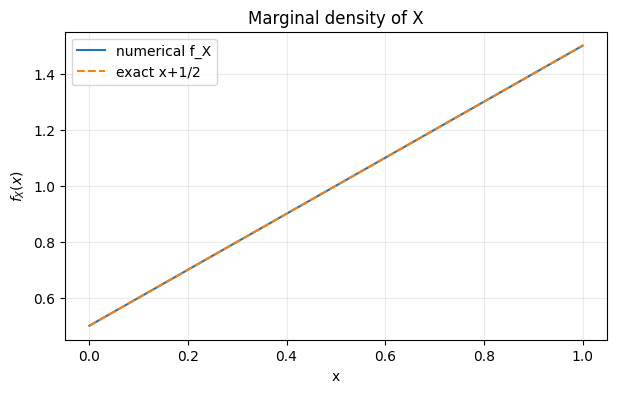

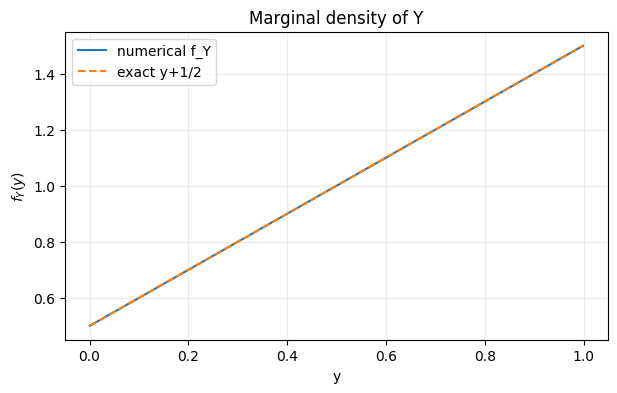

Integral of f_X: 1.0
Integral of f_Y: 1.0


In [5]:
x, y, X, Y, dx, dy = midpoint_grid(0, 1, 0, 1, nx=600, ny=600)
F = f_square(X, Y)

fx_num = marginal_x_from_grid(F, x, y, dy)
fy_num = marginal_y_from_grid(F, x, y, dx)

fx_exact = x + 0.5
fy_exact = y + 0.5

plt.figure(figsize=(7, 4))
plt.plot(x, fx_num, label="numerical f_X")
plt.plot(x, fx_exact, linestyle="--", label="exact x+1/2")
plt.xlabel("x")
plt.ylabel(r"$f_X(x)$")
plt.title("Marginal density of X")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(y, fy_num, label="numerical f_Y")
plt.plot(y, fy_exact, linestyle="--", label="exact y+1/2")
plt.xlabel("y")
plt.ylabel(r"$f_Y(y)$")
plt.title("Marginal density of Y")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print("Integral of f_X:", np.sum(fx_num)*dx)
print("Integral of f_Y:", np.sum(fy_num)*dy)

## 5. Conditional densities

The conditional density of $Y$ given $X=x$ is

$$
f_{Y\mid X}(y\mid x)=\frac{f_{X,Y}(x,y)}{f_X(x)}.
$$

For $f(x,y)=x+y$,

$$
f_{Y\mid X}(y\mid x)=\frac{x+y}{x+1/2}.
$$

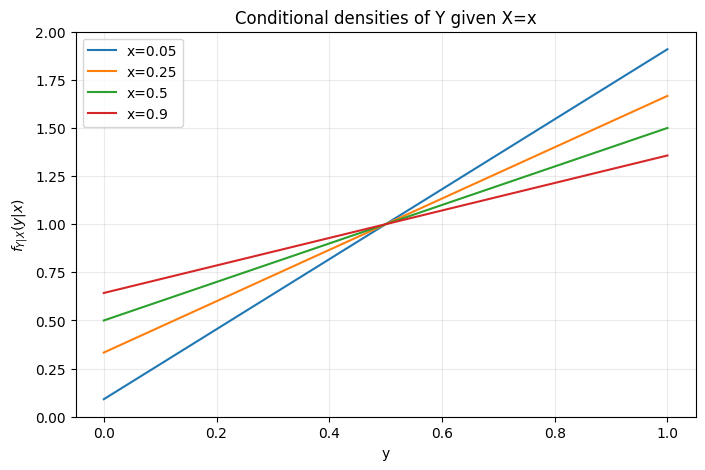

x=0.05, integral over y ≈ 1.000000
x=0.25, integral over y ≈ 1.000000
x=0.50, integral over y ≈ 1.000000
x=0.90, integral over y ≈ 1.000000


In [6]:
x_values = [0.05, 0.25, 0.5, 0.9]
yy = np.linspace(0, 1, 500)

plt.figure(figsize=(8, 5))
for x0 in x_values:
    conditional = (x0 + yy)/(x0 + 0.5)
    plt.plot(yy, conditional, label=f"x={x0}")
plt.xlabel("y")
plt.ylabel(r"$f_{Y|X}(y|x)$")
plt.title("Conditional densities of Y given X=x")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

for x0 in x_values:
    integral = np.trapezoid((x0 + yy)/(x0 + 0.5), yy)
    print(f"x={x0:.2f}, integral over y ≈ {integral:.6f}")

---

# Part III. Expectations, covariance, and correlation

For a joint density $f(x,y)$,

$$
E[g(X,Y)]=\iint g(x,y)f(x,y)\,dA.
$$

In particular,

$$
E[X]=\iint x f(x,y)\,dA,
\qquad
E[Y]=\iint y f(x,y)\,dA.
$$

The covariance is

$$
\operatorname{Cov}(X,Y)=E[XY]-E[X]E[Y].
$$

## 6. Moments of the square density

In [7]:
EX = expectation_from_density(lambda X, Y: X, f_square, 0, 1, 0, 1, nx=700, ny=700)
EY = expectation_from_density(lambda X, Y: Y, f_square, 0, 1, 0, 1, nx=700, ny=700)
EX2 = expectation_from_density(lambda X, Y: X**2, f_square, 0, 1, 0, 1, nx=700, ny=700)
EY2 = expectation_from_density(lambda X, Y: Y**2, f_square, 0, 1, 0, 1, nx=700, ny=700)
EXY = expectation_from_density(lambda X, Y: X*Y, f_square, 0, 1, 0, 1, nx=700, ny=700)

VarX = EX2 - EX**2
VarY = EY2 - EY**2
CovXY = EXY - EX*EY
CorrXY = CovXY/np.sqrt(VarX*VarY)

print("E[X]:", EX)
print("E[Y]:", EY)
print("Var(X):", VarX)
print("Var(Y):", VarY)
print("E[XY]:", EXY)
print("Cov(X,Y):", CovXY)
print("Corr(X,Y):", CorrXY)

E[X]: 0.5833331632653062
E[Y]: 0.5833331632653062
Var(X): 0.07638874716550392
Var(Y): 0.07638874716550392
E[XY]: 0.33333316326530615
Cov(X,Y): -0.006944416099802175
Corr(X,Y): -0.09090888851412103


## 7. Independence check

If $X$ and $Y$ are independent, then

$$
f_{X,Y}(x,y)=f_X(x)f_Y(y).
$$

For $f(x,y)=x+y$, this fails.  
Even though the support is a rectangle, the density does not factor into a function of $x$ times a function of $y$.

Maximum absolute difference f - f_X f_Y: 0.24916736111111115
Mean difference: 1.0658141036401502e-18


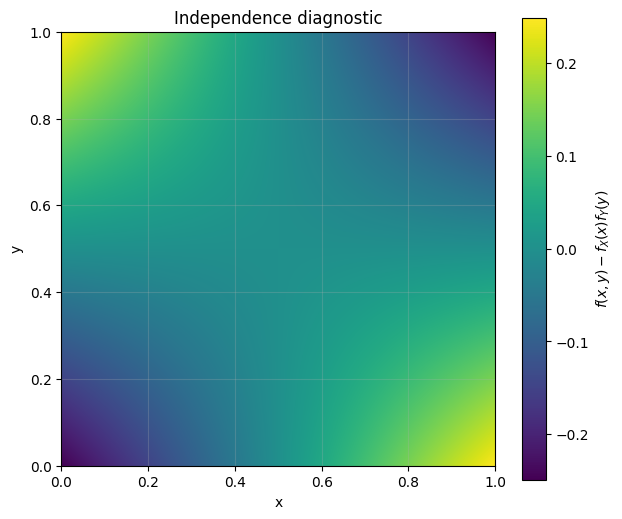

In [8]:
# Compare f(x,y) with f_X(x) f_Y(y) on the midpoint grid.
FXFY = (X + 0.5)*(Y + 0.5)
difference = F - FXFY

print("Maximum absolute difference f - f_X f_Y:", np.max(np.abs(difference)))
print("Mean difference:", np.mean(difference))

plt.figure(figsize=(7, 6))
im = plt.imshow(difference, extent=[0,1,0,1], origin="lower", aspect="equal")
plt.colorbar(im, label=r"$f(x,y)-f_X(x)f_Y(y)$")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Independence diagnostic")
plt.grid(True, alpha=0.25)
plt.show()

---

# Part IV. Densities on triangular regions

Joint densities often live on non-rectangular regions.

Consider the triangular region

$$
D=\{(x,y):x\geq0,\ y\geq0,\ x+y\leq1\}.
$$

Let the density be constant on $D$:

$$
f(x,y)=2.
$$

The factor $2$ normalizes the density because the triangle area is $1/2$.

## 8. Uniform distribution on a triangle

Integral of f=2 over triangle: 1.0014285714285713


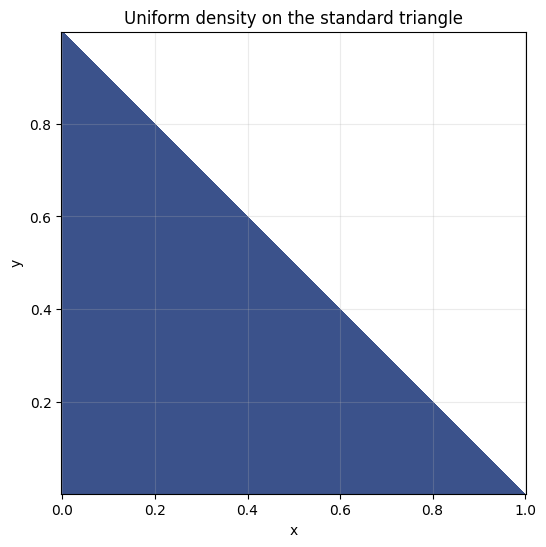

In [9]:
def f_triangle_uniform(X, Y):
    return 2*np.ones_like(X)

prob_tri_total, Xt, Yt, Zt, inside_tri, *_ = integrate_region(
    f_triangle_uniform,
    0, 1, 0, 1,
    mask_triangle,
    nx=700,
    ny=700
)

print("Integral of f=2 over triangle:", prob_tri_total)

plt.figure(figsize=(6, 6))
plt.contourf(Xt, Yt, np.where(inside_tri, 2.0, np.nan), levels=12)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Uniform density on the standard triangle")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

## 9. Moments on the triangle

For a uniform distribution on the standard triangle,

$$
E[X]=E[Y]=\frac13.
$$

The covariance is negative because if $X$ is large, $Y$ must be smaller due to the constraint $x+y\leq1$.

In [10]:
EX_tri, *_ = integrate_region(lambda X, Y: X*f_triangle_uniform(X, Y), 0, 1, 0, 1, mask_triangle, nx=700, ny=700)
EY_tri, *_ = integrate_region(lambda X, Y: Y*f_triangle_uniform(X, Y), 0, 1, 0, 1, mask_triangle, nx=700, ny=700)
EXY_tri, *_ = integrate_region(lambda X, Y: X*Y*f_triangle_uniform(X, Y), 0, 1, 0, 1, mask_triangle, nx=700, ny=700)
EX2_tri, *_ = integrate_region(lambda X, Y: X**2*f_triangle_uniform(X, Y), 0, 1, 0, 1, mask_triangle, nx=700, ny=700)
EY2_tri, *_ = integrate_region(lambda X, Y: Y**2*f_triangle_uniform(X, Y), 0, 1, 0, 1, mask_triangle, nx=700, ny=700)

VarX_tri = EX2_tri - EX_tri**2
VarY_tri = EY2_tri - EY_tri**2
Cov_tri = EXY_tri - EX_tri*EY_tri
Corr_tri = Cov_tri/np.sqrt(VarX_tri*VarY_tri)

print("E[X]:", EX_tri)
print("E[Y]:", EY_tri)
print("Var(X):", VarX_tri)
print("Var(Y):", VarY_tri)
print("Cov(X,Y):", Cov_tri)
print("Corr(X,Y):", Corr_tri)

E[X]: 0.33404795918367347
E[Y]: 0.33404795918367347
Var(X): 0.05555498793315283
Var(Y): 0.05555498793315286
Cov(X,Y): -0.02801627008433985
Corr(X,Y): -0.5042980140334247


---

# Part V. Change of variables and Jacobians in probability

If

$$
(X,Y)=T(U,V),
$$

then densities transform using the Jacobian.

For a one-to-one transformation,

$$
f_{X,Y}(x,y)
=
f_{U,V}(u,v)
\left|
\frac{\partial(u,v)}{\partial(x,y)}
\right|.
$$

Equivalently, in integral form,

$$
f_{X,Y}(x(u,v),y(u,v))
\left|
\frac{\partial(x,y)}{\partial(u,v)}
\right|
=
f_{U,V}(u,v).
$$

## 10. Polar coordinates and uniform disk sampling

Uniform points in the unit disk do **not** have $R$ uniformly distributed on $[0,1]$.

For uniform area in the disk,

$$
P(R\leq r)=r^2,
$$

so the radial density is

$$
f_R(r)=2r.
$$

A correct sampling method is

$$
R=\sqrt U,\qquad \Theta=2\pi V.
$$

In [11]:
rng = np.random.default_rng(24)
n = 50_000

# Incorrect radial sampling
R_bad = rng.uniform(0, 1, n)
Theta_bad = rng.uniform(0, 2*np.pi, n)
X_bad = R_bad*np.cos(Theta_bad)
Y_bad = R_bad*np.sin(Theta_bad)

# Correct area-uniform sampling
U = rng.uniform(0, 1, n)
V = rng.uniform(0, 1, n)
R_good = np.sqrt(U)
Theta_good = 2*np.pi*V
X_good = R_good*np.cos(Theta_good)
Y_good = R_good*np.sin(Theta_good)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_bad[:5000], Y_bad[:5000], s=3, alpha=0.45)
axes[0].set_title("Incorrect: R uniform")
axes[0].axis("equal")
axes[0].grid(True, alpha=0.25)

axes[1].scatter(X_good[:5000], Y_good[:5000], s=3, alpha=0.45)
axes[1].set_title(r"Correct: $R=\sqrt U$")
axes[1].axis("equal")
axes[1].grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(7, 4))
bins = np.linspace(0, 1, 45)
plt.hist(R_bad, bins=bins, density=True, alpha=0.6, label="incorrect R uniform")
plt.hist(R_good, bins=bins, density=True, alpha=0.6, label=r"correct $R=\sqrt U$")
rline = np.linspace(0, 1, 300)
plt.plot(rline, 2*rline, linewidth=3, label=r"target density $2r$")
plt.xlabel("r")
plt.ylabel("density")
plt.title("Radial density in a uniform disk")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

ValueError: 
R=\sqrt U
        ^
ParseSyntaxException: Expected \sqrt{value}, found 'U'  (at char 8), (line:1, col:9)

<Figure size 1200x500 with 2 Axes>

ValueError: 
R=\sqrt U
        ^
ParseSyntaxException: Expected \sqrt{value}, found 'U'  (at char 8), (line:1, col:9)

<Figure size 700x400 with 1 Axes>

## 11. Transformation: square to triangle

Let

$$
U,V\sim \operatorname{Uniform}(0,1)
$$

and define

$$
X=U,\qquad Y=(1-U)V.
$$

Then $(X,Y)$ lies in the triangle $0\leq x,\ 0\leq y,\ x+y\leq1$.

The Jacobian is

$$
\left|\frac{\partial(x,y)}{\partial(u,v)}\right|=1-u.
$$

Therefore the resulting density on the triangle is not uniform:

$$
f_{X,Y}(x,y)=\frac{1}{1-x}.
$$

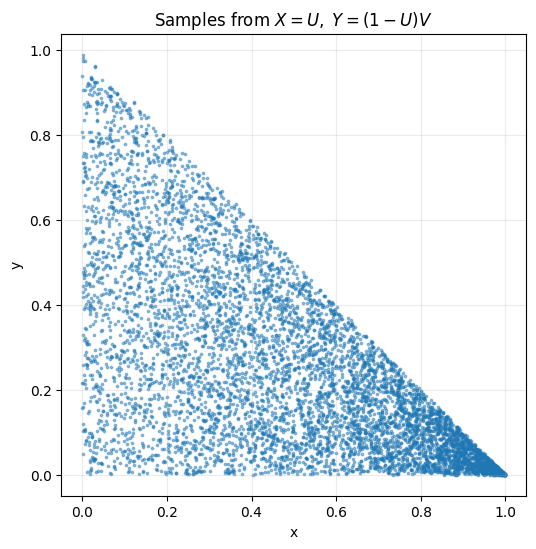

Sample mean X: 0.5010684010168734
Sample mean Y: 0.2500385433419847
Theory: E[X]=1/2, E[Y]=E[(1-U)V]=1/4


In [12]:
n = 60_000
U = rng.uniform(0, 1, n)
V = rng.uniform(0, 1, n)
X_trans = U
Y_trans = (1-U)*V

plt.figure(figsize=(6, 6))
plt.scatter(X_trans[:7000], Y_trans[:7000], s=3, alpha=0.45)
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Samples from $X=U,\;Y=(1-U)V$")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

print("Sample mean X:", np.mean(X_trans))
print("Sample mean Y:", np.mean(Y_trans))
print("Theory: E[X]=1/2, E[Y]=E[(1-U)V]=1/4")

### Guided task 1

Modify the transformation so that the points are uniform in the standard triangle.  
One standard method uses sorted uniforms:

$$
X=\min(U,V),\qquad Y=\max(U,V)-\min(U,V).
$$

Then $X,Y\geq0$ and $X+Y\leq1$.

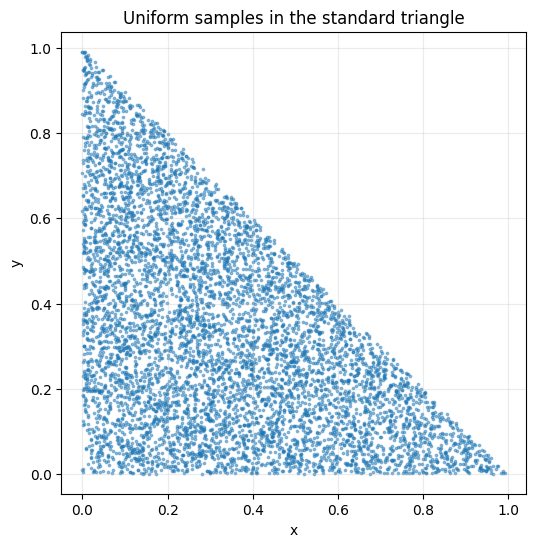

Sample mean X: 0.3332736035768164
Sample mean Y: 0.3316924076372207
Theory for uniform triangle: E[X]=E[Y]=1/3


In [13]:
U = rng.uniform(0, 1, n)
V = rng.uniform(0, 1, n)
A = np.minimum(U, V)
B = np.maximum(U, V)
X_uni_tri = A
Y_uni_tri = B - A

plt.figure(figsize=(6, 6))
plt.scatter(X_uni_tri[:7000], Y_uni_tri[:7000], s=3, alpha=0.45)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Uniform samples in the standard triangle")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

print("Sample mean X:", np.mean(X_uni_tri))
print("Sample mean Y:", np.mean(Y_uni_tri))
print("Theory for uniform triangle: E[X]=E[Y]=1/3")

---

# Part VI. Bivariate normal distributions and quadratic forms

The bivariate normal density has the form

$$
f(x,y)
=
\frac{1}{2\pi\sqrt{\det\Sigma}}
\exp\left[
-\frac12
(\mathbf x-\mu)^T\Sigma^{-1}(\mathbf x-\mu)
\right].
$$

The exponent contains a quadratic form.  
The covariance matrix $\Sigma$ controls the shape and orientation of the contours.

## 12. Visualize a bivariate normal density

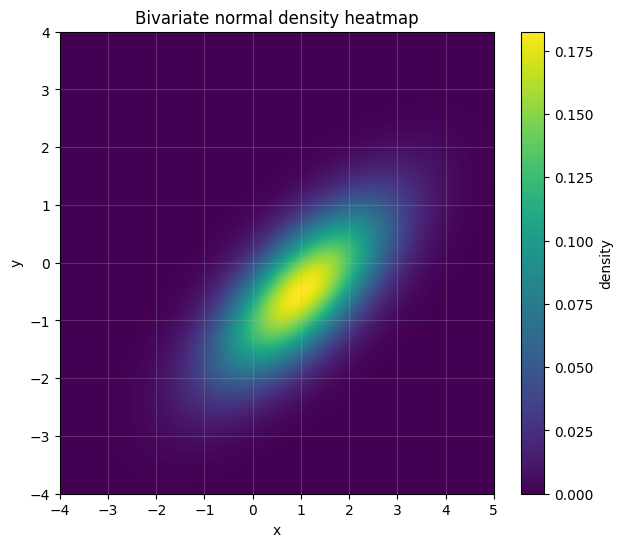

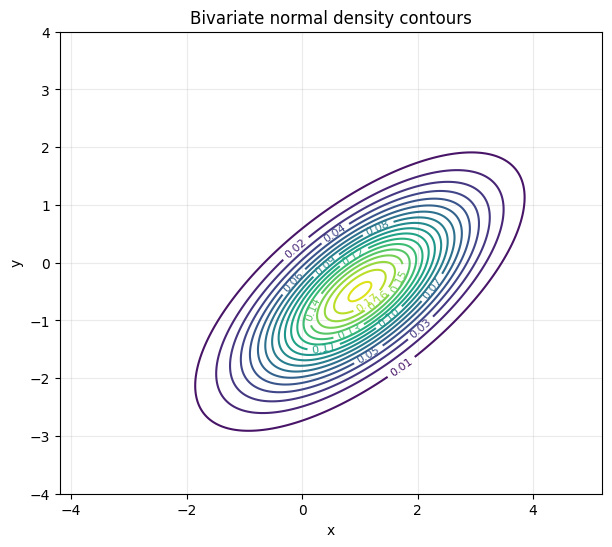

Mean vector: [ 1.  -0.5]
Covariance matrix:
[[1.4 0.8]
 [0.8 1. ]]
Eigenvalues: [0.375379 2.024621]
Correlation: 0.6761234037828133


In [14]:
mu = np.array([1.0, -0.5])
Sigma = np.array([[1.4, 0.8],
                  [0.8, 1.0]])

def f_bvn(X, Y):
    return bivariate_normal_pdf(X, Y, mu, Sigma)

Xb, Yb, Zb = plot_density_heatmap(
    f_bvn,
    -4, 5,
    -4, 4,
    n=450,
    title="Bivariate normal density heatmap"
)

plot_density_contour(
    f_bvn,
    -4, 5,
    -4, 4,
    n=450,
    title="Bivariate normal density contours",
    levels=18
)

print("Mean vector:", mu)
print("Covariance matrix:")
print(Sigma)
print("Eigenvalues:", np.linalg.eigvalsh(Sigma))
print("Correlation:", Sigma[0,1]/np.sqrt(Sigma[0,0]*Sigma[1,1]))

## 13. Covariance ellipses

Level curves of the bivariate normal density are ellipses:

$$
(\mathbf x-\mu)^T\Sigma^{-1}(\mathbf x-\mu)=c^2.
$$

Eigenvectors of $\Sigma$ give the ellipse directions.  
Eigenvalues give the squared axis lengths, up to the level factor.

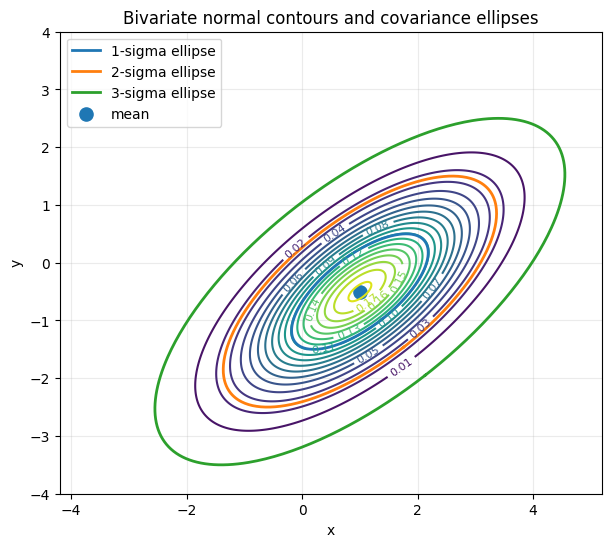

In [15]:
plt.figure(figsize=(7, 6))
cs = plt.contour(Xb, Yb, Zb, levels=18)
plt.clabel(cs, inline=True, fontsize=8)
for level in [1, 2, 3]:
    xe, ye = covariance_ellipse_points(mu, Sigma, level=level)
    plt.plot(xe, ye, linewidth=2, label=f"{level}-sigma ellipse")
plt.scatter([mu[0]], [mu[1]], s=90, label="mean")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Bivariate normal contours and covariance ellipses")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 14. Numerical normalization check

A bivariate normal is supported on all of $\mathbb R^2$.  
We approximate its total probability on a large rectangle.

In [16]:
for L in [2, 3, 4, 5, 6]:
    val, *_ = integrate_rect(f_bvn, mu[0]-L, mu[0]+L, mu[1]-L, mu[1]+L, nx=600, ny=600)
    print(f"rectangle half-width {L}: probability ≈ {val:.8f}")

rectangle half-width 2: probability ≈ 0.88415050
rectangle half-width 3: probability ≈ 0.98698138
rectangle half-width 4: probability ≈ 0.99922883
rectangle half-width 5: probability ≈ 0.99997571
rectangle half-width 6: probability ≈ 0.99999960


---

# Part VII. Monte Carlo integration and expectation

Monte Carlo approximates expectations using samples:

$$
E[g(X,Y)]\approx \frac1n\sum_{i=1}^n g(X_i,Y_i).
$$

This is often easier than high-dimensional integration.

## 15. Monte Carlo expectations for a bivariate normal

Monte Carlo estimate: 0.30302935455613755
Monte Carlo SE: 0.008322160161059362
Theoretical value: 0.30000000000000004


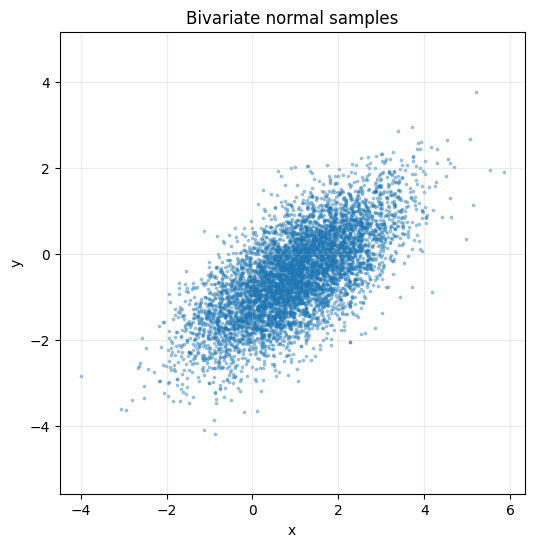

In [17]:
def bvn_sampler(rng, n):
    return rng.multivariate_normal(mu, Sigma, size=n)

def g_for_mc(X, Y):
    return X + 2*Y + X*Y

mc_est, mc_se, samples = monte_carlo_expectation(g_for_mc, bvn_sampler, n=200_000, seed=240)

# Theory:
# E[X+2Y+XY] = EX + 2EY + Cov(X,Y)+EX*EY.
theory = mu[0] + 2*mu[1] + Sigma[0,1] + mu[0]*mu[1]

print("Monte Carlo estimate:", mc_est)
print("Monte Carlo SE:", mc_se)
print("Theoretical value:", theory)

plt.figure(figsize=(6, 6))
plt.scatter(samples[:6000,0], samples[:6000,1], s=3, alpha=0.35)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Bivariate normal samples")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

---

# Part VIII. Maximum likelihood as multivariable calculus

A likelihood is a function of parameters.

For data $x_1,\ldots,x_n$ from a normal model with mean $\mu$ and standard deviation $\sigma$, the log-likelihood is

$$
\ell(\mu,\sigma)
=
-n\log\sigma
-\frac{1}{2\sigma^2}\sum_{i=1}^n(x_i-\mu)^2
+\text{constant}.
$$

We can study $\ell$ as a function of two variables.

## 16. Simulate normal data and plot the log-likelihood surface

MLE mu: 1.9780672323908068
MLE sigma: 1.4353948358567727


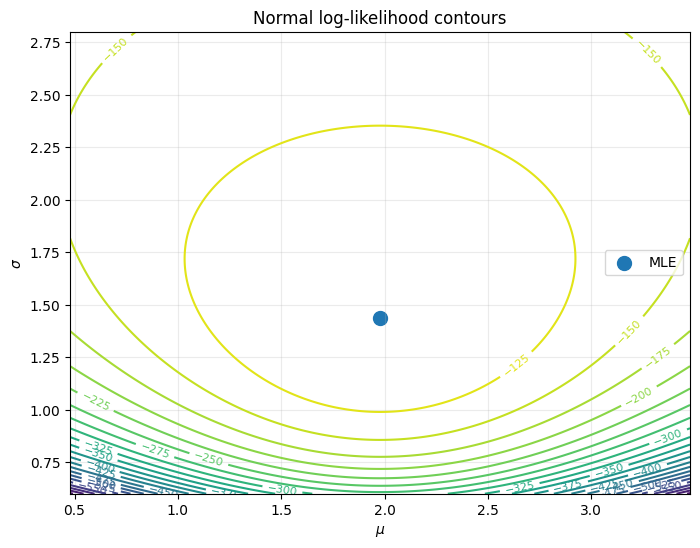

In [18]:
rng = np.random.default_rng(241)
data = rng.normal(loc=2.0, scale=1.5, size=120)

def loglik_normal(theta):
    mu0, sigma0 = theta
    if sigma0 <= 0:
        return -np.inf
    n = len(data)
    return -n*np.log(sigma0) - np.sum((data-mu0)**2)/(2*sigma0**2)

mu_grid = np.linspace(np.mean(data)-1.5, np.mean(data)+1.5, 220)
sigma_grid = np.linspace(0.6, 2.8, 220)
MU, SIG = np.meshgrid(mu_grid, sigma_grid)
LL = np.zeros_like(MU)

for i in range(MU.shape[0]):
    for j in range(MU.shape[1]):
        LL[i,j] = loglik_normal([MU[i,j], SIG[i,j]])

mle_mu = np.mean(data)
mle_sigma = np.sqrt(np.mean((data-mle_mu)**2))

print("MLE mu:", mle_mu)
print("MLE sigma:", mle_sigma)

plt.figure(figsize=(8, 6))
cs = plt.contour(MU, SIG, LL, levels=25)
plt.clabel(cs, inline=True, fontsize=8)
plt.scatter([mle_mu], [mle_sigma], s=100, label="MLE")
plt.xlabel(r"$\mu$")
plt.ylabel(r"$\sigma$")
plt.title("Normal log-likelihood contours")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 17. Score vector and Hessian at the MLE

The gradient of the log-likelihood is called the **score**.

At an interior maximum,

$$
\nabla \ell(\widehat\mu,\widehat\sigma)=0.
$$

The Hessian at a local maximum should be negative definite.

In [19]:
mle = np.array([mle_mu, mle_sigma])

score_num = finite_gradient(loglik_normal, mle)
H_num = finite_hessian(loglik_normal, mle)

eigvals = np.linalg.eigvalsh(H_num)

print("Numerical score at MLE:", score_num)
print("Numerical Hessian at MLE:")
print(H_num)
print("Hessian eigenvalues:", eigvals)
print("Negative definite?", np.all(eigvals < 0))

Numerical score at MLE: [-0.  0.]
Numerical Hessian at MLE:
[[ -58.242296    0.      ]
 [   0.       -116.484597]]
Hessian eigenvalues: [-116.484597  -58.242296]
Negative definite? True


## 18. Quadratic approximation of the log-likelihood

Near the MLE, the log-likelihood is approximately quadratic:

$$
\ell(\theta)
\approx
\ell(\widehat\theta)
+
\frac12(\theta-\widehat\theta)^T
H(\widehat\theta)
(\theta-\widehat\theta).
$$

The negative Hessian measures local curvature and is related to information.

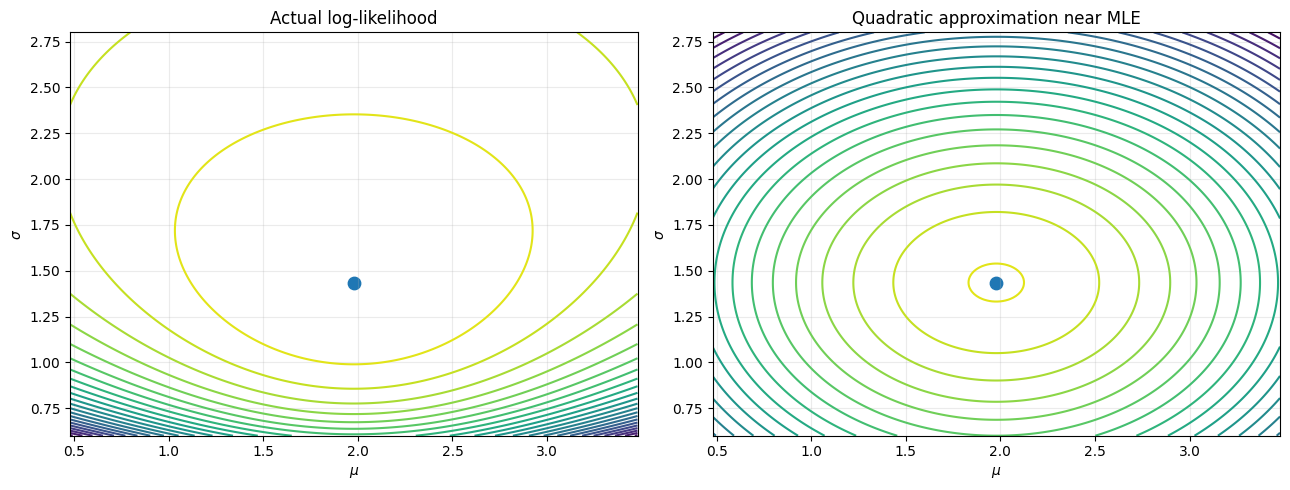

In [20]:
ll_mle = loglik_normal(mle)

def ll_quad(MU, SIG):
    D0 = MU - mle[0]
    D1 = SIG - mle[1]
    return ll_mle + 0.5*(H_num[0,0]*D0**2 + 2*H_num[0,1]*D0*D1 + H_num[1,1]*D1**2)

LLQ = ll_quad(MU, SIG)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cs0 = axes[0].contour(MU, SIG, LL, levels=25)
axes[0].scatter([mle_mu], [mle_sigma], s=80)
axes[0].set_title("Actual log-likelihood")
axes[0].set_xlabel(r"$\mu$")
axes[0].set_ylabel(r"$\sigma$")
axes[0].grid(True, alpha=0.25)

cs1 = axes[1].contour(MU, SIG, LLQ, levels=25)
axes[1].scatter([mle_mu], [mle_sigma], s=80)
axes[1].set_title("Quadratic approximation near MLE")
axes[1].set_xlabel(r"$\mu$")
axes[1].set_ylabel(r"$\sigma$")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

---

# Part IX. Logistic regression likelihood

Many statistical models use multivariable calculus to optimize a loss function.

For logistic regression with one predictor,

$$
p_i=\frac{1}{1+e^{-(\beta_0+\beta_1x_i)}}.
$$

The negative log-likelihood is

$$
L(\beta)
=
-\sum_i
\left[
y_i\log p_i+(1-y_i)\log(1-p_i)
\right].
$$

The gradient and Hessian are central to optimization.

## 19. Simulate binary data and optimize by gradient descent

Estimated beta by gradient descent: [-0.430164  1.930566]
True beta: [-0.4  1.7]
Final gradient: [ 0. -0.]
Final Hessian eigenvalues: [10.898851 28.731423]


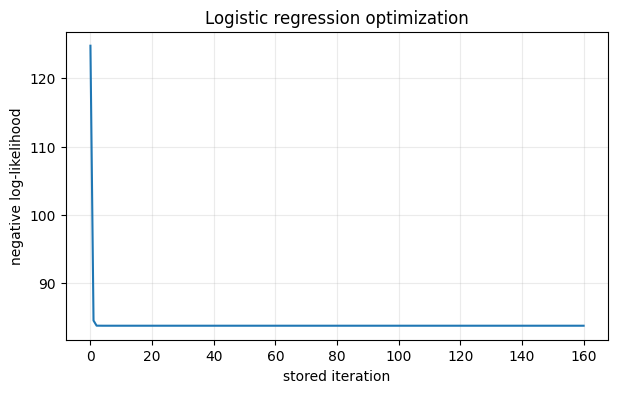

In [21]:
rng = np.random.default_rng(242)
n = 180
x_data = rng.normal(size=n)
true_beta = np.array([-0.4, 1.7])
eta_true = true_beta[0] + true_beta[1]*x_data
p_true = 1/(1 + np.exp(-eta_true))
y_data = rng.binomial(1, p_true)

X_design = np.column_stack([np.ones(n), x_data])

def sigmoid(z):
    return 1/(1+np.exp(-z))

def logistic_loss(beta):
    beta = np.asarray(beta, dtype=float)
    eta = X_design @ beta
    # stable negative log-likelihood: log(1+exp(eta)) - y eta
    return float(np.sum(np.logaddexp(0, eta) - y_data*eta))

def logistic_grad(beta):
    beta = np.asarray(beta, dtype=float)
    p = sigmoid(X_design @ beta)
    return X_design.T @ (p - y_data)

def logistic_hess(beta):
    beta = np.asarray(beta, dtype=float)
    p = sigmoid(X_design @ beta)
    w = p*(1-p)
    return X_design.T @ (X_design*w[:,None])

beta = np.array([0.0, 0.0])
eta_step = 0.03
path = [beta.copy()]
losses = [logistic_loss(beta)]

for k in range(800):
    beta = beta - eta_step*logistic_grad(beta)
    if k % 5 == 0:
        path.append(beta.copy())
        losses.append(logistic_loss(beta))

path = np.array(path)
losses = np.array(losses)

print("Estimated beta by gradient descent:", beta)
print("True beta:", true_beta)
print("Final gradient:", logistic_grad(beta))
print("Final Hessian eigenvalues:", np.linalg.eigvalsh(logistic_hess(beta)))

plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("stored iteration")
plt.ylabel("negative log-likelihood")
plt.title("Logistic regression optimization")
plt.grid(True, alpha=0.25)
plt.show()

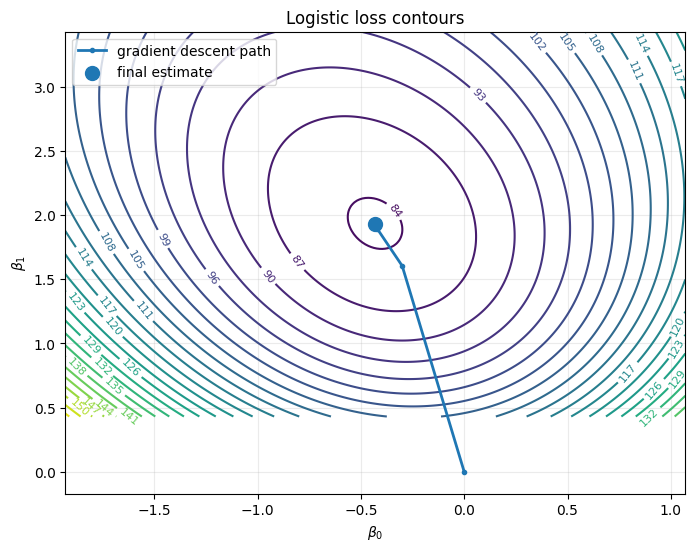

In [22]:
b0_grid = np.linspace(beta[0]-1.5, beta[0]+1.5, 220)
b1_grid = np.linspace(beta[1]-1.5, beta[1]+1.5, 220)
B0, B1 = np.meshgrid(b0_grid, b1_grid)
LossGrid = np.zeros_like(B0)

for i in range(B0.shape[0]):
    for j in range(B0.shape[1]):
        LossGrid[i,j] = logistic_loss([B0[i,j], B1[i,j]])

plt.figure(figsize=(8, 6))
cs = plt.contour(B0, B1, LossGrid, levels=28)
plt.clabel(cs, inline=True, fontsize=8)
plt.plot(path[:,0], path[:,1], marker="o", markersize=3, linewidth=2, label="gradient descent path")
plt.scatter([beta[0]], [beta[1]], s=100, label="final estimate")
plt.xlabel(r"$\beta_0$")
plt.ylabel(r"$\beta_1$")
plt.title("Logistic loss contours")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

---

# Part X. Bayesian posterior surfaces

Bayesian inference often produces a posterior density over several parameters:

$$
p(\theta\mid\text{data})
\propto
p(\text{data}\mid\theta)p(\theta).
$$

The proportionality constant is an integral:

$$
p(\theta\mid\text{data})
=
\frac{p(\text{data}\mid\theta)p(\theta)}
{\int p(\text{data}\mid\theta)p(\theta)\,d\theta}.
$$

## 20. Posterior over $(\mu,\sigma)$ for normal data

We build an unnormalized posterior on a grid.

Use a simple prior:

$$
\mu\sim N(0,5^2),
$$

and use a weak positive prior for $\sigma$ proportional to

$$
e^{-\sigma/5},\qquad \sigma>0.
$$

Posterior grid integrates to: 1.0
Posterior mean mu: 1.9766664424721667
Posterior SD mu: 0.13305659448072577
Posterior mean sigma: 1.454958880605986
Posterior SD sigma: 0.09544254063522696


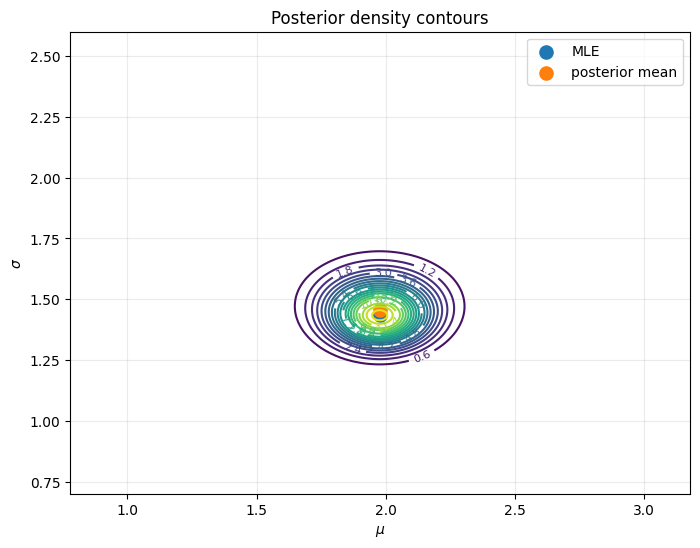

In [23]:
def log_prior_mu_sigma(mu0, sigma0):
    if sigma0 <= 0:
        return -np.inf
    return -0.5*(mu0/5)**2 - sigma0/5

def log_posterior(theta):
    mu0, sigma0 = theta
    return loglik_normal(theta) + log_prior_mu_sigma(mu0, sigma0)

mu_grid = np.linspace(mle_mu-1.2, mle_mu+1.2, 260)
sigma_grid = np.linspace(0.7, 2.6, 240)
MU, SIG = np.meshgrid(mu_grid, sigma_grid)
LP = np.zeros_like(MU)

for i in range(MU.shape[0]):
    for j in range(MU.shape[1]):
        LP[i,j] = log_posterior([MU[i,j], SIG[i,j]])

# Stabilize before exponentiating.
LP_shift = LP - np.max(LP)
unnormalized = np.exp(LP_shift)

dmu = mu_grid[1] - mu_grid[0]
dsigma = sigma_grid[1] - sigma_grid[0]
posterior_grid, posterior_normalizer_shifted = normalize_grid_density(unnormalized, dmu, dsigma)

post_mu_mean = np.sum(MU*posterior_grid)*dmu*dsigma
post_sigma_mean = np.sum(SIG*posterior_grid)*dmu*dsigma
post_mu_sd = np.sqrt(np.sum((MU-post_mu_mean)**2*posterior_grid)*dmu*dsigma)
post_sigma_sd = np.sqrt(np.sum((SIG-post_sigma_mean)**2*posterior_grid)*dmu*dsigma)

print("Posterior grid integrates to:", np.sum(posterior_grid)*dmu*dsigma)
print("Posterior mean mu:", post_mu_mean)
print("Posterior SD mu:", post_mu_sd)
print("Posterior mean sigma:", post_sigma_mean)
print("Posterior SD sigma:", post_sigma_sd)

plt.figure(figsize=(8, 6))
cs = plt.contour(MU, SIG, posterior_grid, levels=24)
plt.clabel(cs, inline=True, fontsize=8)
plt.scatter([mle_mu], [mle_sigma], s=90, label="MLE")
plt.scatter([post_mu_mean], [post_sigma_mean], s=90, label="posterior mean")
plt.xlabel(r"$\mu$")
plt.ylabel(r"$\sigma$")
plt.title("Posterior density contours")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 21. Marginal posterior densities

To get marginal posterior densities, integrate out the other parameter:

$$
p(\mu\mid\text{data})=\int p(\mu,\sigma\mid\text{data})\,d\sigma,
$$

$$
p(\sigma\mid\text{data})=\int p(\mu,\sigma\mid\text{data})\,d\mu.
$$

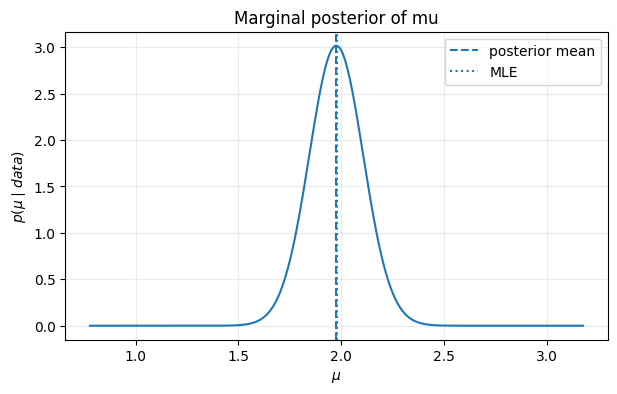

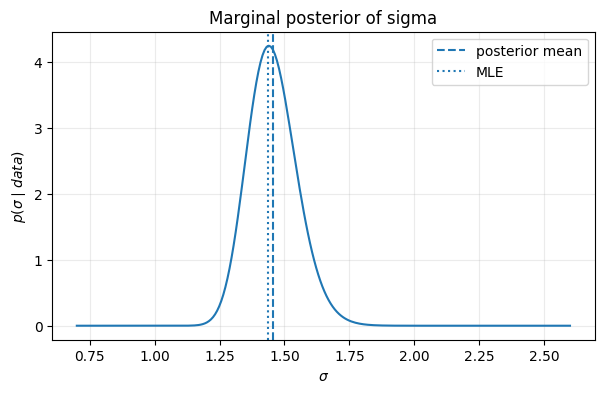

Integral of marginal mu density: 1.0
Integral of marginal sigma density: 1.0


In [24]:
posterior_mu_marg = np.sum(posterior_grid, axis=0)*dsigma
posterior_sigma_marg = np.sum(posterior_grid, axis=1)*dmu

plt.figure(figsize=(7, 4))
plt.plot(mu_grid, posterior_mu_marg)
plt.axvline(post_mu_mean, linestyle="--", label="posterior mean")
plt.axvline(mle_mu, linestyle=":", label="MLE")
plt.xlabel(r"$\mu$")
plt.ylabel(r"$p(\mu\mid data)$")
plt.title("Marginal posterior of mu")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(sigma_grid, posterior_sigma_marg)
plt.axvline(post_sigma_mean, linestyle="--", label="posterior mean")
plt.axvline(mle_sigma, linestyle=":", label="MLE")
plt.xlabel(r"$\sigma$")
plt.ylabel(r"$p(\sigma\mid data)$")
plt.title("Marginal posterior of sigma")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print("Integral of marginal mu density:", np.sum(posterior_mu_marg)*dmu)
print("Integral of marginal sigma density:", np.sum(posterior_sigma_marg)*dsigma)

---

# Part XI. Delta method intuition

The delta method uses Taylor approximation to estimate uncertainty after transformation.

If $\hat\theta$ is approximately normal with variance $\operatorname{Var}(\hat\theta)$ and $g$ is smooth, then

$$
\operatorname{Var}(g(\hat\theta))
\approx
[g'(\theta)]^2\operatorname{Var}(\hat\theta).
$$

In multiple dimensions,

$$
\operatorname{Var}(g(\hat\theta))
\approx
\nabla g(\theta)^T
\Sigma
\nabla g(\theta).
$$

## 22. Multivariable delta method simulation

Let

$$
(\hat a,\hat b)\sim N(\theta,\Sigma),
$$

and let

$$
g(a,b)=\frac{a}{b}.
$$

Then

$$
\nabla g(a,b)=\left\langle \frac1b,\;-\frac{a}{b^2}\right\rangle.
$$

Delta-method mean approximation: 0.5
Simulation mean: 0.5022616402297861
Delta-method SD: 0.057282196186948006
Simulation SD: 0.05792409951476591


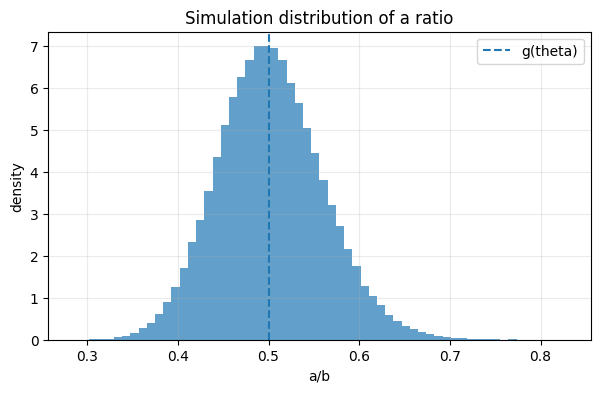

In [25]:
theta0 = np.array([2.0, 4.0])
Sigma_hat = np.array([[0.04, 0.01],
                      [0.01, 0.09]])

def g_ratio(A, B):
    return A/B

grad_g = np.array([1/theta0[1], -theta0[0]/theta0[1]**2])
delta_var = grad_g @ Sigma_hat @ grad_g
delta_sd = np.sqrt(delta_var)

rng = np.random.default_rng(243)
sim = rng.multivariate_normal(theta0, Sigma_hat, size=200_000)
g_sim = g_ratio(sim[:,0], sim[:,1])

print("Delta-method mean approximation:", g_ratio(theta0[0], theta0[1]))
print("Simulation mean:", np.mean(g_sim))
print("Delta-method SD:", delta_sd)
print("Simulation SD:", np.std(g_sim, ddof=1))

plt.figure(figsize=(7, 4))
plt.hist(g_sim, bins=60, density=True, alpha=0.7)
plt.axvline(g_ratio(theta0[0], theta0[1]), linestyle="--", label="g(theta)")
plt.xlabel("a/b")
plt.ylabel("density")
plt.title("Simulation distribution of a ratio")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

---

# Part XII. Chapter mini-project: probabilistic model fitting

In this mini-project, we combine probability, integration, and optimization.

We fit a two-parameter model to bivariate data:

$$
Y_i=\alpha+\beta X_i+\varepsilon_i,
\qquad
\varepsilon_i\sim N(0,\sigma^2),
$$

where $\sigma$ is known.

The negative log-likelihood, up to an additive constant, is

$$
L(\alpha,\beta)
=
\frac{1}{2\sigma^2}
\sum_i(y_i-\alpha-\beta x_i)^2.
$$

This is a quadratic function of $(\alpha,\beta)$.

You will:

1. simulate data;
2. plot the likelihood surface;
3. find the maximum likelihood estimate;
4. compute the Hessian;
5. interpret covariance of the estimator;
6. compare confidence ellipses with likelihood contours.

## 23. Simulate linear data and fit by least squares

True parameters: [ 1.  -0.8]
MLE/least-squares estimate: [ 1.090998 -0.836176]


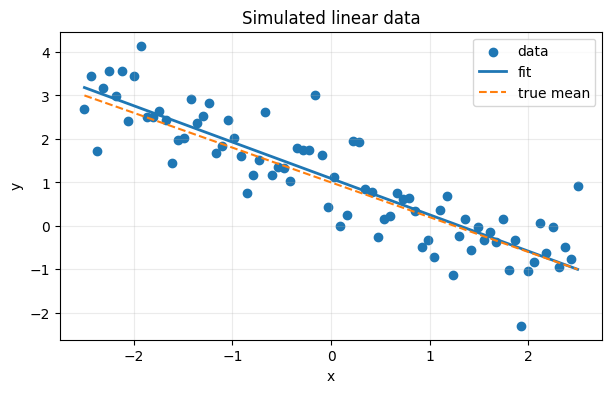

In [26]:
rng = np.random.default_rng(244)

n = 80
sigma_known = 0.7
x_lin = np.linspace(-2.5, 2.5, n)
alpha_true = 1.0
beta_true = -0.8
y_lin = alpha_true + beta_true*x_lin + rng.normal(scale=sigma_known, size=n)

A = np.column_stack([np.ones(n), x_lin])
theta_hat = np.linalg.lstsq(A, y_lin, rcond=None)[0]

print("True parameters:", np.array([alpha_true, beta_true]))
print("MLE/least-squares estimate:", theta_hat)

plt.figure(figsize=(7, 4))
plt.scatter(x_lin, y_lin, label="data")
plt.plot(x_lin, A @ theta_hat, linewidth=2, label="fit")
plt.plot(x_lin, alpha_true + beta_true*x_lin, linestyle="--", label="true mean")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Simulated linear data")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 24. Likelihood surface and Hessian

Gradient at estimate: [-0. -0.]
Hessian:
[[163.265306   0.      ]
 [  0.       348.747094]]
Approximate covariance matrix of estimator:
[[ 0.006125 -0.      ]
 [-0.        0.002867]]


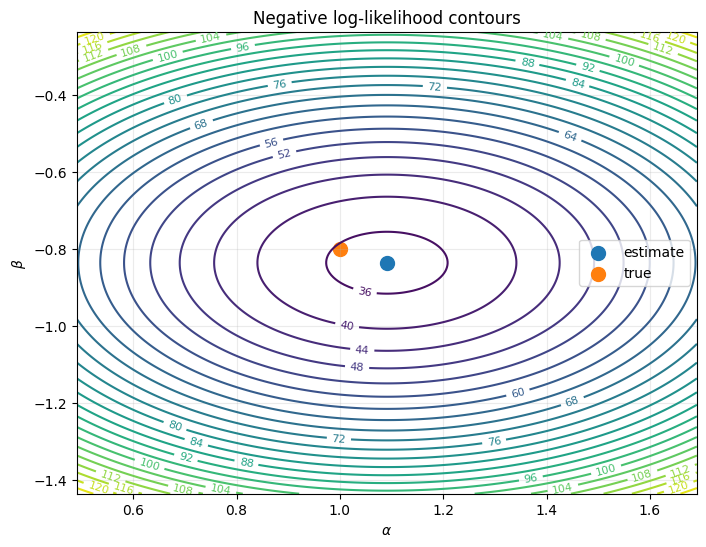

In [27]:
def linear_negloglik(theta):
    alpha, beta = theta
    residual = y_lin - alpha - beta*x_lin
    return float(np.sum(residual**2)/(2*sigma_known**2))

def linear_grad(theta):
    alpha, beta = theta
    residual = y_lin - alpha - beta*x_lin
    return np.array([
        -np.sum(residual)/sigma_known**2,
        -np.sum(x_lin*residual)/sigma_known**2
    ])

def linear_hess(theta):
    return (A.T @ A)/sigma_known**2

H_lin = linear_hess(theta_hat)
cov_theta_hat = np.linalg.inv(H_lin)

print("Gradient at estimate:", linear_grad(theta_hat))
print("Hessian:")
print(H_lin)
print("Approximate covariance matrix of estimator:")
print(cov_theta_hat)

a_grid = np.linspace(theta_hat[0]-0.6, theta_hat[0]+0.6, 240)
b_grid = np.linspace(theta_hat[1]-0.6, theta_hat[1]+0.6, 240)
AA, BB = np.meshgrid(a_grid, b_grid)
Lgrid = np.zeros_like(AA)
for i in range(AA.shape[0]):
    for j in range(AA.shape[1]):
        Lgrid[i,j] = linear_negloglik([AA[i,j], BB[i,j]])

plt.figure(figsize=(8, 6))
cs = plt.contour(AA, BB, Lgrid, levels=28)
plt.clabel(cs, inline=True, fontsize=8)
plt.scatter([theta_hat[0]], [theta_hat[1]], s=100, label="estimate")
plt.scatter([alpha_true], [beta_true], s=100, label="true")
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\beta$")
plt.title("Negative log-likelihood contours")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 25. Covariance ellipse for the estimator

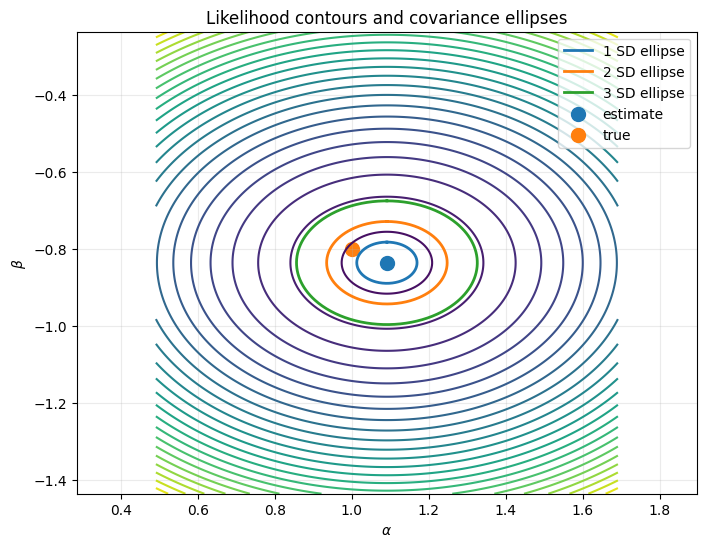

In [28]:
plt.figure(figsize=(8, 6))
cs = plt.contour(AA, BB, Lgrid, levels=28)
for level in [1, 2, 3]:
    xe, ye = covariance_ellipse_points(theta_hat, cov_theta_hat, level=level)
    plt.plot(xe, ye, linewidth=2, label=f"{level} SD ellipse")
plt.scatter([theta_hat[0]], [theta_hat[1]], s=100, label="estimate")
plt.scatter([alpha_true], [beta_true], s=100, label="true")
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\beta$")
plt.title("Likelihood contours and covariance ellipses")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 26. Mini-project questions

Answer the following in a markdown cell:

1. Why is the negative log-likelihood quadratic in $(\alpha,\beta)$?
2. What does the Hessian tell you about parameter uncertainty?
3. Why are the likelihood contours ellipses?
4. What does covariance between $\hat\alpha$ and $\hat\beta$ mean geometrically?
5. How would the plot change if the data had less noise?
6. How would the plot change if all $x_i$ values were closer together?

In [29]:
print("Mini-project summary")
print("--------------------")
print("theta_hat =", theta_hat)
print("Hessian =")
print(H_lin)
print("covariance approximation =")
print(cov_theta_hat)
print("standard errors =", np.sqrt(np.diag(cov_theta_hat)))
print("parameter correlation =", cov_theta_hat[0,1]/np.sqrt(cov_theta_hat[0,0]*cov_theta_hat[1,1]))

Mini-project summary
--------------------
theta_hat = [ 1.090998 -0.836176]
Hessian =
[[163.265306   0.      ]
 [  0.       348.747094]]
covariance approximation =
[[ 0.006125 -0.      ]
 [-0.        0.002867]]
standard errors = [0.078262 0.053548]
parameter correlation = -7.596296095031369e-17


---

# Part XIII. Additional exercises with reference solutions

Try each exercise before running the reference solution.

## Exercise A. Normalize a density

Find the constant $c$ so that

$$
f(x,y)=cxy
$$

is a density on $0\leq x\leq1$, $0\leq y\leq1$.

In [30]:
# Exercise A workspace

# Your code here

### Reference solution for Exercise A

In [31]:
base_integral, *_ = integrate_rect(lambda X, Y: X*Y, 0, 1, 0, 1, nx=500, ny=500)
c_A = 1/base_integral
print("Integral of xy:", base_integral)
print("Normalizing constant c:", c_A)
print("Exact c:", 4.0)

Integral of xy: 0.25
Normalizing constant c: 4.0
Exact c: 4.0


## Exercise B. Marginal density

For the density

$$
f(x,y)=4xy
$$

on the unit square, compute $f_X(x)$ and check numerically that it integrates to $1$.

In [32]:
# Exercise B workspace

# Your code here

### Reference solution for Exercise B

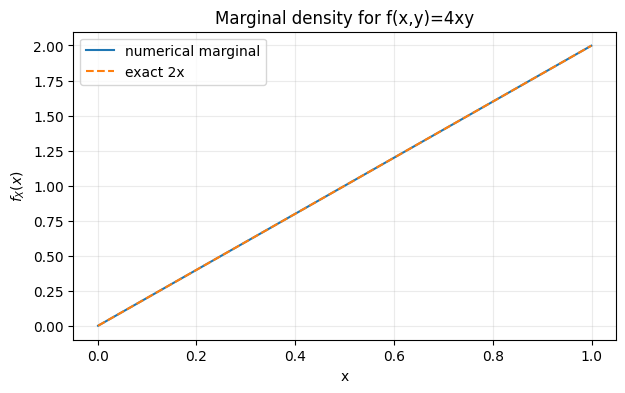

Integral of f_X: 1.0


In [33]:
x, y, X, Y, dx, dy = midpoint_grid(0, 1, 0, 1, nx=500, ny=500)
F_B = 4*X*Y
fx_B = marginal_x_from_grid(F_B, x, y, dy)

plt.figure(figsize=(7, 4))
plt.plot(x, fx_B, label="numerical marginal")
plt.plot(x, 2*x, linestyle="--", label="exact 2x")
plt.xlabel("x")
plt.ylabel(r"$f_X(x)$")
plt.title("Marginal density for f(x,y)=4xy")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print("Integral of f_X:", np.sum(fx_B)*dx)

## Exercise C. Covariance

For independent densities $f_X(x)=2x$ and $f_Y(y)=2y$ on $[0,1]$, the joint density is

$$
f(x,y)=4xy.
$$

Compute the covariance numerically.

In [34]:
# Exercise C workspace

# Your code here

### Reference solution for Exercise C

In [35]:
def f_C(X, Y):
    return 4*X*Y

EX_C = expectation_from_density(lambda X, Y: X, f_C, 0, 1, 0, 1)
EY_C = expectation_from_density(lambda X, Y: Y, f_C, 0, 1, 0, 1)
EXY_C = expectation_from_density(lambda X, Y: X*Y, f_C, 0, 1, 0, 1)
Cov_C = EXY_C - EX_C*EY_C

print("E[X]:", EX_C)
print("E[Y]:", EY_C)
print("E[XY]:", EXY_C)
print("Covariance:", Cov_C)

E[X]: 0.6666660000000001
E[Y]: 0.6666660000000001
E[XY]: 0.444443555556
Covariance: -1.1102230246251565e-16


## Exercise D. Bivariate normal probability

For a bivariate normal with mean $0$ and identity covariance, estimate

$$
P(X^2+Y^2\leq1)
$$

by Monte Carlo.

In [36]:
# Exercise D workspace

# Your code here

### Reference solution for Exercise D

In [37]:
rng = np.random.default_rng(245)
samples_D = rng.normal(size=(300_000, 2))
prob_D = np.mean(np.sum(samples_D**2, axis=1) <= 1)

# For 2D standard normal, radius^2 has chi-square_2 distribution, so P(R^2<=1)=1-exp(-1/2).
exact_D = 1 - np.exp(-0.5)

print("Monte Carlo estimate:", prob_D)
print("Exact value:", exact_D)

Monte Carlo estimate: 0.39369333333333334
Exact value: 0.3934693402873666


## Exercise E. MLE curvature

For normal data with known $\sigma=1$, the negative log-likelihood for $\mu$ is

$$
L(\mu)=\frac12\sum_i(x_i-\mu)^2.
$$

Show numerically that the second derivative is $n$.

In [38]:
# Exercise E workspace

# Your code here

### Reference solution for Exercise E

In [39]:
data_E = rng.normal(loc=1.0, scale=1.0, size=50)

def L_mu(mu):
    return 0.5*np.sum((data_E-mu)**2)

mu_hat_E = np.mean(data_E)
h = 1e-4
second_derivative = (L_mu(mu_hat_E+h) - 2*L_mu(mu_hat_E) + L_mu(mu_hat_E-h))/h**2

print("n:", len(data_E))
print("Numerical second derivative at MLE:", second_derivative)

n: 50
Numerical second derivative at MLE: 49.999999873762135


---

# Formula summary

## Joint density

$$
f_{X,Y}(x,y)\geq0,\qquad
\iint f_{X,Y}(x,y)\,dA=1.
$$

## Probability of a region

$$
P((X,Y)\in D)=\iint_D f_{X,Y}(x,y)\,dA.
$$

## Marginal densities

$$
f_X(x)=\int f_{X,Y}(x,y)\,dy,
\qquad
f_Y(y)=\int f_{X,Y}(x,y)\,dx.
$$

## Conditional density

$$
f_{Y\mid X}(y\mid x)=\frac{f_{X,Y}(x,y)}{f_X(x)}.
$$

## Expectation

$$
E[g(X,Y)]=\iint g(x,y)f_{X,Y}(x,y)\,dA.
$$

## Covariance

$$
\operatorname{Cov}(X,Y)=E[XY]-E[X]E[Y].
$$

## Change of variables for densities

If $(X,Y)=T(U,V)$, then

$$
f_{X,Y}(x,y)=
f_{U,V}(u,v)
\left|
\frac{\partial(u,v)}{\partial(x,y)}
\right|.
$$

## Bivariate normal density

$$
f(x)=
\frac{1}{2\pi\sqrt{\det\Sigma}}
\exp\left[
-\frac12(x-\mu)^T\Sigma^{-1}(x-\mu)
\right].
$$

## Score and Hessian

For log-likelihood $\ell(\theta)$,

$$
\text{score}=\nabla\ell(\theta),
\qquad
H=\nabla^2\ell(\theta).
$$

At an interior maximum,

$$
\nabla\ell(\widehat\theta)=0,
$$

and the Hessian is typically negative definite.

## Bayesian normalization

$$
p(\theta\mid data)=
\frac{p(data\mid\theta)p(\theta)}
{\int p(data\mid\theta)p(\theta)\,d\theta}.
$$

## Multivariable delta method

$$
\operatorname{Var}(g(\hat\theta))
\approx
\nabla g(\theta)^T\Sigma\nabla g(\theta).
$$

# End of Chapter 24 Lab

You have used Python to explore:

- joint densities and normalization,
- probabilities as double integrals,
- marginal and conditional densities,
- moments, covariance, and correlation,
- non-rectangular probability regions,
- transformations and Jacobians,
- uniform disk and triangle sampling,
- bivariate normal geometry,
- Monte Carlo expectation,
- maximum likelihood surfaces,
- gradients and Hessians,
- logistic regression optimization,
- Bayesian posterior surfaces,
- posterior marginals,
- the delta method,
- and a likelihood-based model-fitting mini-project.

These ideas show how multivariable calculus provides the computational and conceptual language of probability, statistics, data science, and inference.